## Exploratory Data Analysis - Practice Project

#### Problem Statement:

There are so many variables that impact the price of a house. With dynamic parameters in the residential real state business, it is always important to reach a reasonable price for better business opportunities. As a part of the analytics team in a real state company, you have to come up with the variables that are impacting the price of the house through analyzing and visualizing the data.

#### Dataset

Download the dataset "housing_data.csv" from Course Resources section

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
housing_df = pd.read_csv("housing_data.csv")

In [5]:
housing_df.head()

,Unnamed: 0,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,0,SC60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,...,0,No,No,No,0,Feb,2008,WD,Normal,208500
1,1,SC20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,...,0,No,No,No,0,May,2007,WD,Normal,181500
2,2,SC60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,...,0,No,No,No,0,Sep,2008,WD,Normal,223500
3,3,SC70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,...,0,No,No,No,0,Feb,2006,WD,Abnorml,140000
4,4,SC60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,...,0,No,No,No,0,Dec,2008,WD,Normal,250000


In [6]:
housing_df.shape

(1460, 81)

In [7]:
housing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     1460 non-null   int64  
 1   MSSubClass     1460 non-null   object 
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          1460 non-null   object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
# Dropping "Unnamed: 0" column

In [8]:
housing_df = housing_df.drop("Unnamed: 0", axis= 1)

In [9]:
housing_df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,SC60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,Inside,...,0,No,No,No,0,Feb,2008,WD,Normal,208500
1,SC20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,FR2,...,0,No,No,No,0,May,2007,WD,Normal,181500
2,SC60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,Inside,...,0,No,No,No,0,Sep,2008,WD,Normal,223500
3,SC70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,Corner,...,0,No,No,No,0,Feb,2006,WD,Abnorml,140000
4,SC60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,FR2,...,0,No,No,No,0,Dec,2008,WD,Normal,250000


In [10]:
housing_df.shape

(1460, 80)

In [ ]:
# Find out the number of numerical features in our dataset:

In [13]:
numeric_columns = housing_df._get_numeric_data().columns

In [14]:
numeric_columns

Index(['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt',
       'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea',
       'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr',
       'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt',
       'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'YrSold', 'SalePrice'],
      dtype='object')

In [15]:
type(numeric_columns)

pandas.core.indexes.base.Index

In [16]:
numeric_columns = list(numeric_columns)

In [17]:
numeric_columns

['LotFrontage',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'YrSold',
 'SalePrice']

In [18]:
type(numeric_columns)

list

In [19]:
object_columns = list(set(housing_df.columns) - set(numeric_columns))

In [20]:
object_columns

['Foundation',
 'BsmtFinType1',
 'Alley',
 'LotShape',
 'Condition2',
 'HouseStyle',
 'FireplaceQu',
 'MSZoning',
 'GarageCond',
 'Neighborhood',
 'MiscFeature',
 'SaleCondition',
 'LotConfig',
 'MoSold',
 'MSSubClass',
 'Condition1',
 'BldgType',
 'Exterior2nd',
 'BsmtExposure',
 'Functional',
 'PavedDrive',
 'Fence',
 'GarageFinish',
 'MasVnrType',
 'Electrical',
 'BsmtFinType2',
 'ExterQual',
 'ExterCond',
 'RoofMatl',
 'Exterior1st',
 'GarageType',
 'HeatingQC',
 'PoolQC',
 'BsmtQual',
 'KitchenQual',
 'CentralAir',
 'GarageQual',
 'SaleType',
 'LandSlope',
 'RoofStyle',
 'Utilities',
 'BsmtCond',
 'LandContour',
 'Heating',
 'Street']

In [21]:
type(object_columns)

list

In [ ]:
# Plot Histogram for 'YearBuilt', 'TotalBsmtSF', 'GrLivArea', and 'SalePrice':

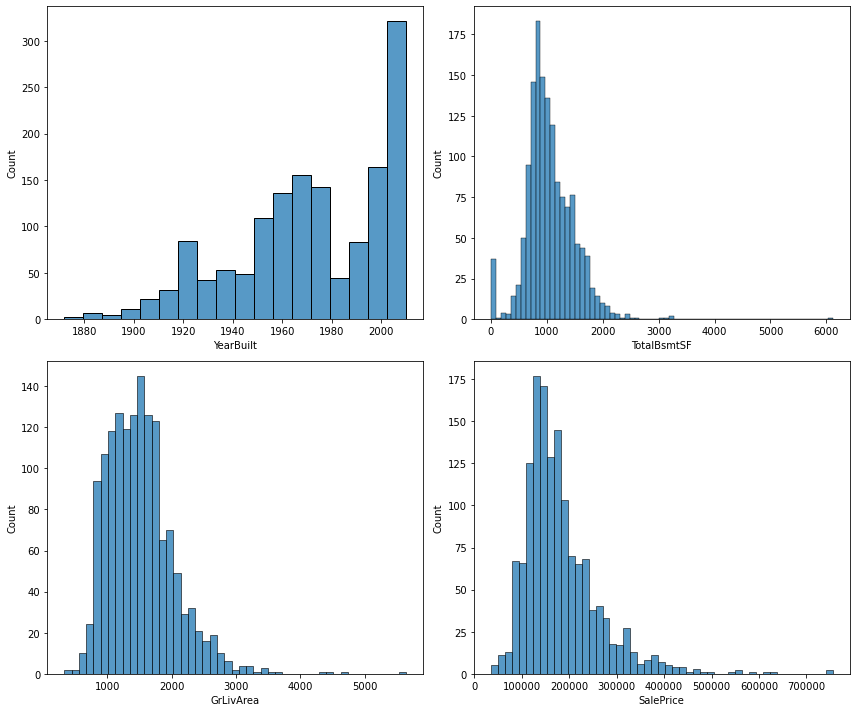

In [40]:
fig, axes = plt.subplots(nrows= 2, ncols= 2, figsize= (12,10))

sns.histplot(housing_df["YearBuilt"], ax= axes[0][0])
sns.histplot(housing_df["TotalBsmtSF"], ax= axes[0][1])
sns.histplot(housing_df["GrLivArea"], ax= axes[1][0])
sns.histplot(housing_df["SalePrice"], ax= axes[1][1])

plt.tight_layout()
plt.show()


In [ ]:
# Plot Kernel Density Function for 'YearBuilt', 'TotalBsmtSF', 'GrLivArea', and 'SalePrice':

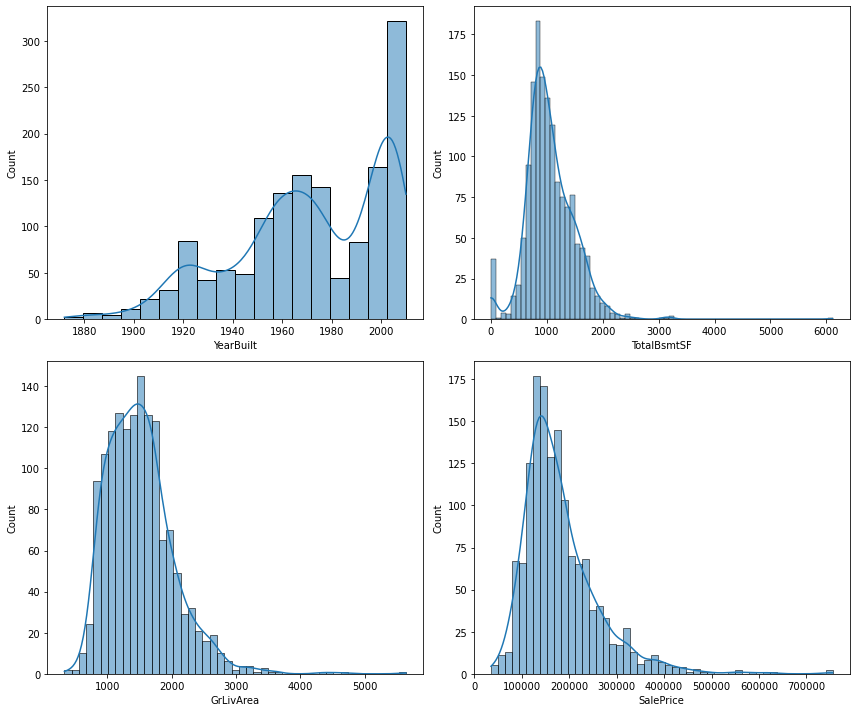

In [47]:
fig, axes = plt.subplots(nrows= 2, ncols= 2, figsize= (12,10))

sns.histplot(housing_df["YearBuilt"], ax= axes[0][0], kde= True)
sns.histplot(housing_df["TotalBsmtSF"], ax= axes[0][1], kde= True)
sns.histplot(housing_df["GrLivArea"], ax= axes[1][0], kde= True)
sns.histplot(housing_df["SalePrice"], ax= axes[1][1], kde= True)

plt.tight_layout()
plt.show()

In [ ]:
# Plot Boxplots for 'YearBuilt', 'TotalBsmtSF', 'GrLivArea', and 'SalePrice':

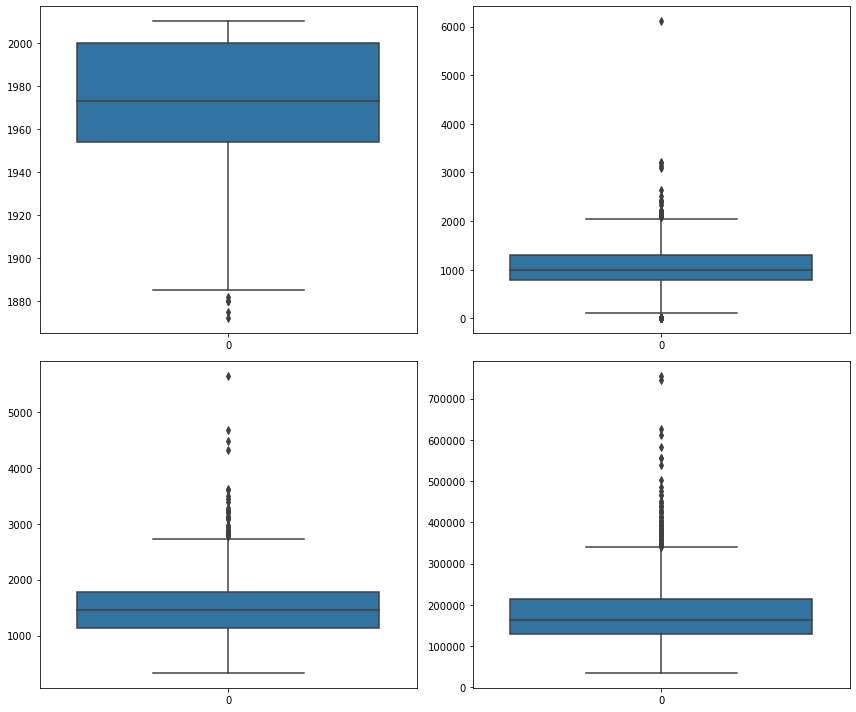

In [48]:
fig, axes = plt.subplots(nrows= 2, ncols= 2, figsize= (12,10))

sns.boxplot(data= housing_df["YearBuilt"], ax= axes[0][0])
sns.boxplot(data= housing_df["TotalBsmtSF"], ax= axes[0][1])
sns.boxplot(data= housing_df["GrLivArea"], ax= axes[1][0])
sns.boxplot(data= housing_df["SalePrice"], ax= axes[1][1])

plt.tight_layout()
plt.show()

In [ ]:
# Countplot for Categorical Feature 'SaleCondition':

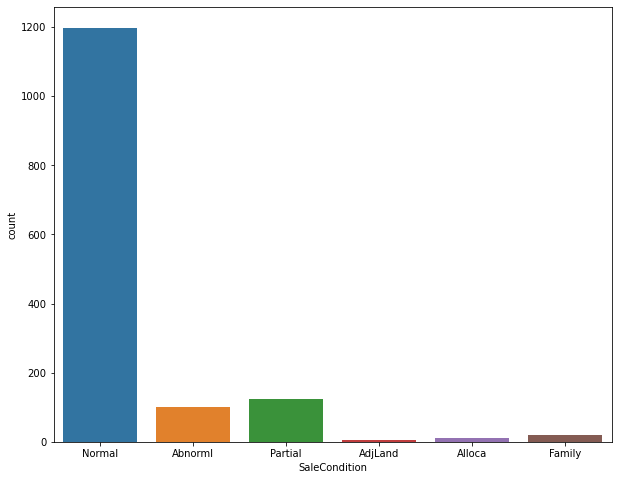

In [51]:
plt.figure(figsize= (10,8))

sns.countplot(data= housing_df, x= "SaleCondition")

plt.show()

In [ ]:
# Countplot For Categorical Feature 'Neighborhood':

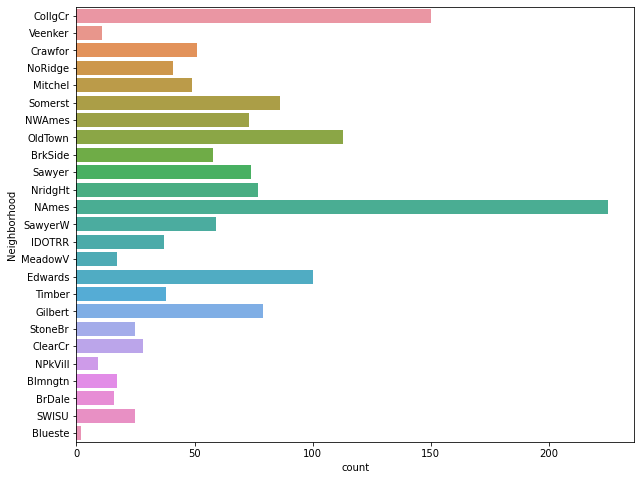

In [53]:
plt.figure(figsize= (10,8))

sns.countplot(data= housing_df, y= "Neighborhood")

plt.show()

In [ ]:
# Plot 'GrLivArea' against 'SalePrice'

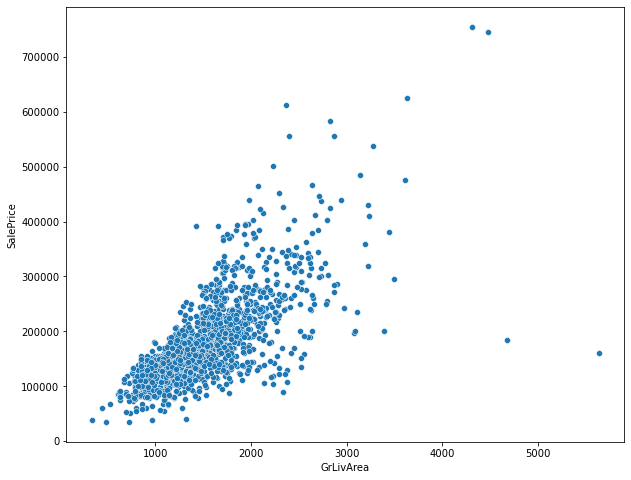

In [54]:
plt.figure(figsize= (10,8))

sns.scatterplot(x= housing_df["GrLivArea"], y= housing_df["SalePrice"])

plt.show()

<Figure size 720x576 with 0 Axes>

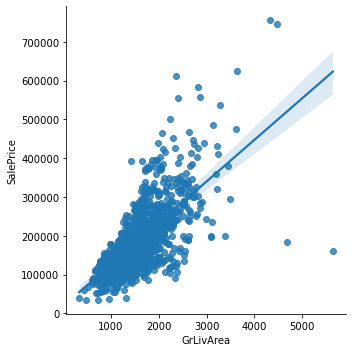

In [57]:
plt.figure(figsize= (10,8))

sns.lmplot(data= housing_df, x= "GrLivArea", y= "SalePrice")

plt.show()

In [ ]:
# Plot 'TotalBsmtSF' against 'SalePrice'

<Figure size 720x576 with 0 Axes>

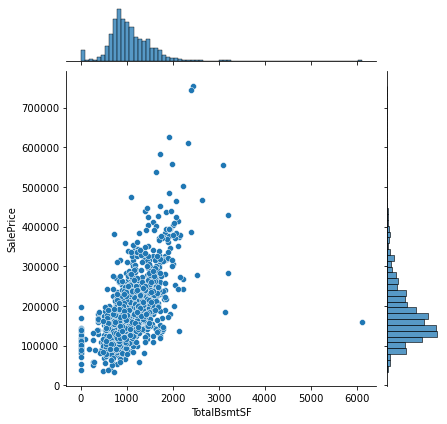

In [59]:
plt.figure(figsize= (10,8))

sns.jointplot(x= housing_df["TotalBsmtSF"], y= housing_df["SalePrice"])

plt.show()

In [ ]:
# Heat Map of Correlation between Features:

In [60]:
corr_df = housing_df.corr()

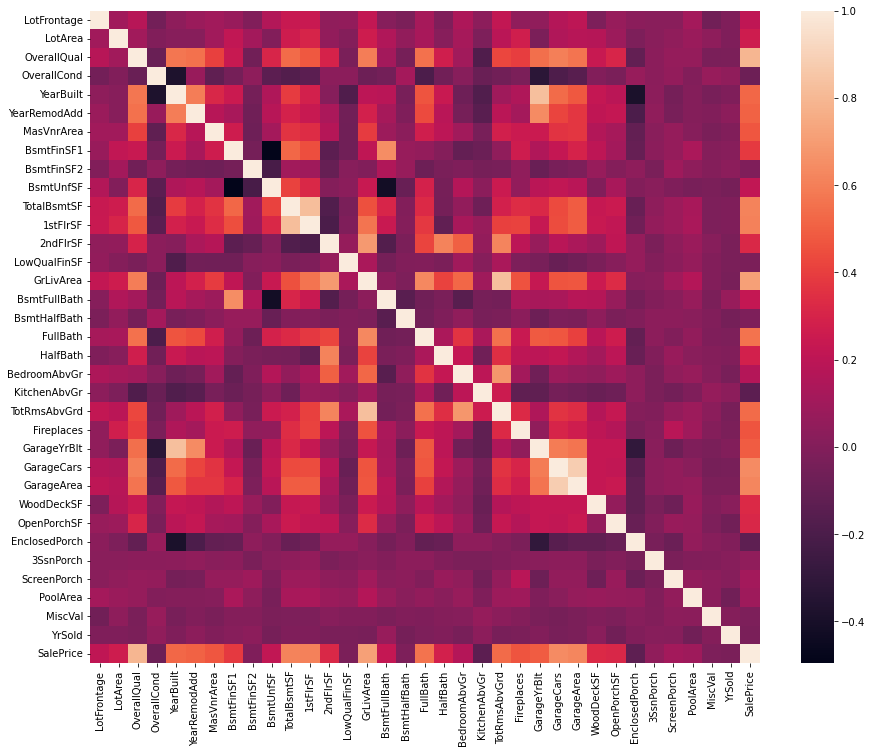

In [64]:
plt.figure(figsize= (15,12))

sns.heatmap(corr_df)

plt.show()

In [98]:
# Finding out top 10 Features with highest correlation witl SalePrice:

In [99]:
corr_df

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,YrSold,SalePrice
LotFrontage,1.000000,0.100739,0.176561,-0.053457,0.036853,0.078686,0.105010,0.076670,-0.009312,0.160829,...,0.201473,-0.016780,0.069605,0.027366,0.023499,0.022969,0.114106,-0.059606,-0.012094,0.209624
LotArea,0.100739,1.000000,0.105806,-0.005636,0.014228,0.013788,0.103321,0.214103,0.111170,-0.002618,...,0.180403,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,-0.014261,0.263843
OverallQual,0.176561,0.105806,1.000000,-0.091932,0.572323,0.550684,0.407252,0.239666,-0.059119,0.308159,...,0.562022,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,-0.027347,0.790982
OverallCond,-0.053457,-0.005636,-0.091932,1.000000,-0.375983,0.073741,-0.125694,-0.046231,0.040229,-0.136841,...,-0.151521,-0.003334,-0.032589,0.070356,0.025504,0.054811,-0.001985,0.068777,0.043950,-0.077856
YearBuilt,0.036853,0.014228,0.572323,-0.375983,1.000000,0.592855,0.311600,0.249503,-0.049107,0.149040,...,0.478954,0.224880,0.188686,-0.387268,0.031355,-0.050364,0.004950,-0.034383,-0.013618,0.522897
YearRemodAdd,0.078686,0.013788,0.550684,0.073741,0.592855,1.000000,0.176529,0.128451,-0.067759,0.181133,...,0.371600,0.205726,0.226298,-0.193919,0.045286,-0.038740,0.005829,-0.010286,0.035743,0.507101
MasVnrArea,0.105010,0.103321,0.407252,-0.125694,0.311600,0.176529,1.000000,0.261256,-0.071330,0.113862,...,0.370884,0.159991,0.122528,-0.109907,0.019144,0.062248,0.011928,-0.029512,-0.008317,0.472614
BsmtFinSF1,0.076670,0.214103,0.239666,-0.046231,0.249503,0.128451,0.261256,1.000000,-0.050117,-0.495251,...,0.296970,0.204306,0.111761,-0.102303,0.026451,0.062021,0.140491,0.003571,0.014359,0.386420
BsmtFinSF2,-0.009312,0.111170,-0.059119,0.040229,-0.049107,-0.067759,-0.071330,-0.050117,1.000000,-0.209294,...,-0.018227,0.067898,0.003093,0.036543,-0.029993,0.088871,0.041709,0.004940,0.031706,-0.011378
BsmtUnfSF,0.160829,-0.002618,0.308159,-0.136841,0.149040,0.181133,0.113862,-0.495251,-0.209294,1.000000,...,0.183303,-0.005316,0.129005,-0.002538,0.020764,-0.012579,-0.035092,-0.023837,-0.041258,0.214479


In [100]:
corr_df["SalePrice"]

LotFrontage      0.209624
LotArea          0.263843
OverallQual      0.790982
OverallCond     -0.077856
YearBuilt        0.522897
YearRemodAdd     0.507101
MasVnrArea       0.472614
BsmtFinSF1       0.386420
BsmtFinSF2      -0.011378
BsmtUnfSF        0.214479
TotalBsmtSF      0.613581
1stFlrSF         0.605852
2ndFlrSF         0.319334
LowQualFinSF    -0.025606
GrLivArea        0.708624
BsmtFullBath     0.227122
BsmtHalfBath    -0.016844
FullBath         0.560664
HalfBath         0.284108
BedroomAbvGr     0.168213
KitchenAbvGr    -0.135907
TotRmsAbvGrd     0.533723
Fireplaces       0.466929
GarageYrBlt      0.486362
GarageCars       0.640409
GarageArea       0.623431
WoodDeckSF       0.324413
OpenPorchSF      0.315856
EnclosedPorch   -0.128578
3SsnPorch        0.044584
ScreenPorch      0.111447
PoolArea         0.092404
MiscVal         -0.021190
YrSold          -0.028923
SalePrice        1.000000
Name: SalePrice, dtype: float64

In [101]:
corr_df[["SalePrice"]].sort_values(by="SalePrice",ascending= False)

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


In [102]:
corr_df[["SalePrice"]].sort_values(by="SalePrice",ascending= False)[0:11]

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


In [103]:
corr_df[["SalePrice"]].sort_values(by="SalePrice",ascending= False)[0:11].index

Index(['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
       'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt',
       'YearRemodAdd'],
      dtype='object')

In [104]:
type(corr_df[["SalePrice"]].sort_values(by="SalePrice",ascending= False)[0:11].index)

pandas.core.indexes.base.Index

In [105]:
top_10_saleP_corr = list(corr_df[["SalePrice"]].sort_values(by="SalePrice",ascending= False)[0:11].index)

In [106]:
top_10_saleP_corr

['SalePrice',
 'OverallQual',
 'GrLivArea',
 'GarageCars',
 'GarageArea',
 'TotalBsmtSF',
 '1stFlrSF',
 'FullBath',
 'TotRmsAbvGrd',
 'YearBuilt',
 'YearRemodAdd']

In [107]:
# Plotting Heatmap of SalePrice with 10 highly correlated features:

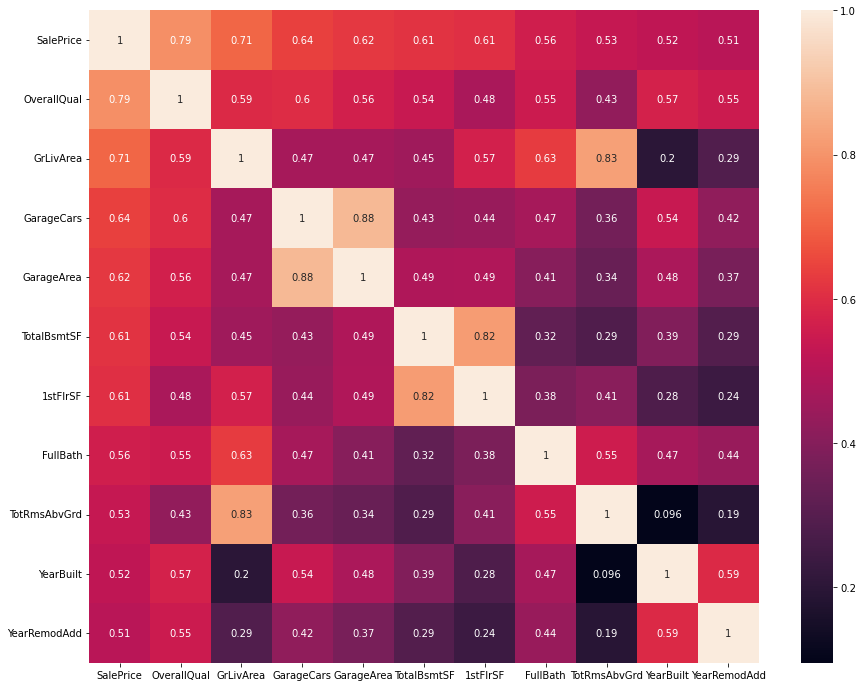

In [109]:
plt.figure(figsize= (15,12))

sns.heatmap(housing_df[top_10_saleP_corr].corr(), annot= True)

plt.show()

In [ ]:
# Visualizing relationship between SalePrice and it's 4 top correlated features:

<Figure size 1080x864 with 0 Axes>

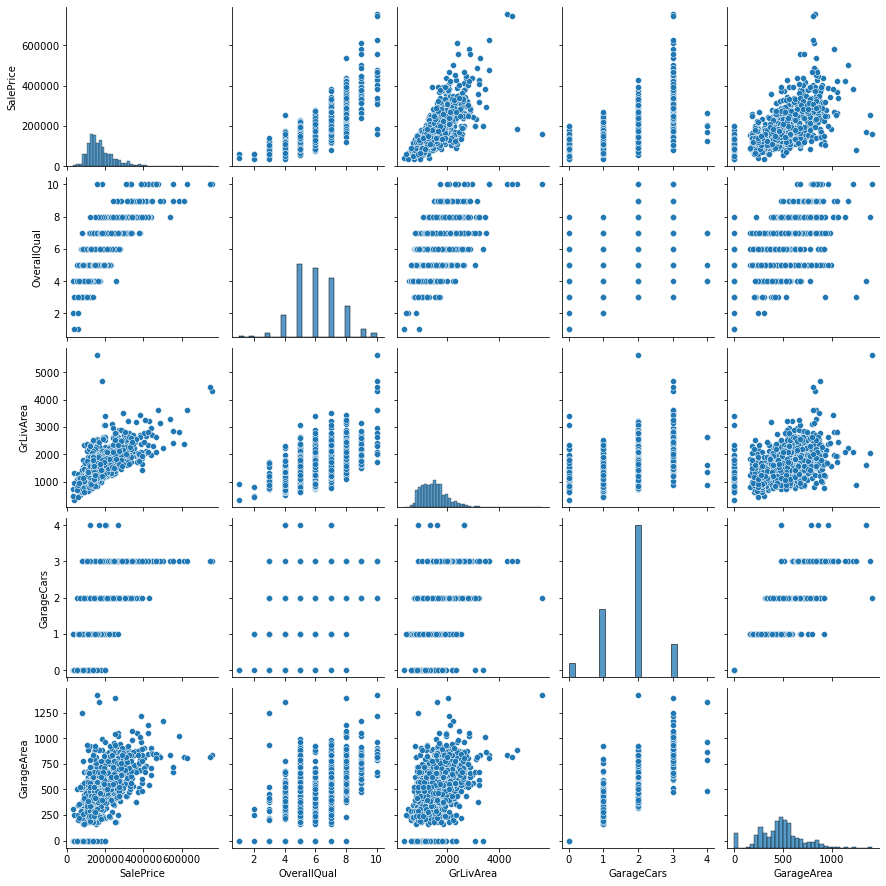

In [110]:
plt.figure(figsize= (15,12))

sns.pairplot(housing_df[top_10_saleP_corr[0:5]])

plt.show()

In [ ]:
# Neighborhood wise SalePrice Distribution:

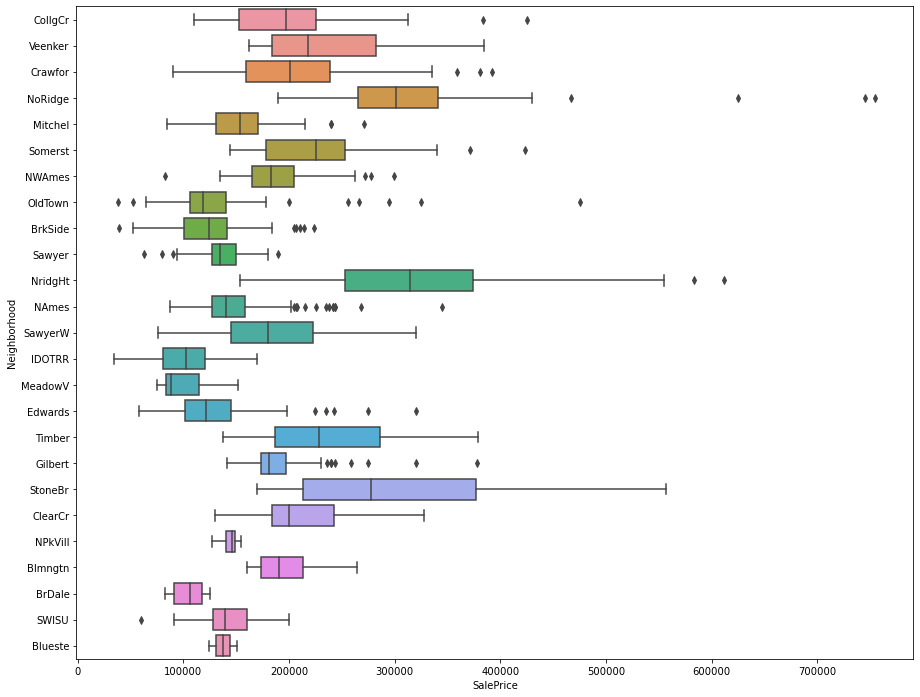

In [112]:
plt.figure(figsize= (15,12))

sns.boxplot(data= housing_df, x="SalePrice", y= "Neighborhood")

plt.show()

In [ ]:
# Overall Quality wise SalePrice Distribution:

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\categorical.py:1296: UserWarning: 6.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\ProgramData\Anaconda3\lib\site-packages\seaborn\categorical.py:1296: UserWarning: 45.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\ProgramData\Anaconda3\lib\site-packages\seaborn\categorical.py:1296: UserWarning: 33.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\ProgramData\Anaconda3\lib\site-packages\seaborn\categorical.py:1296: UserWarning: 20.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


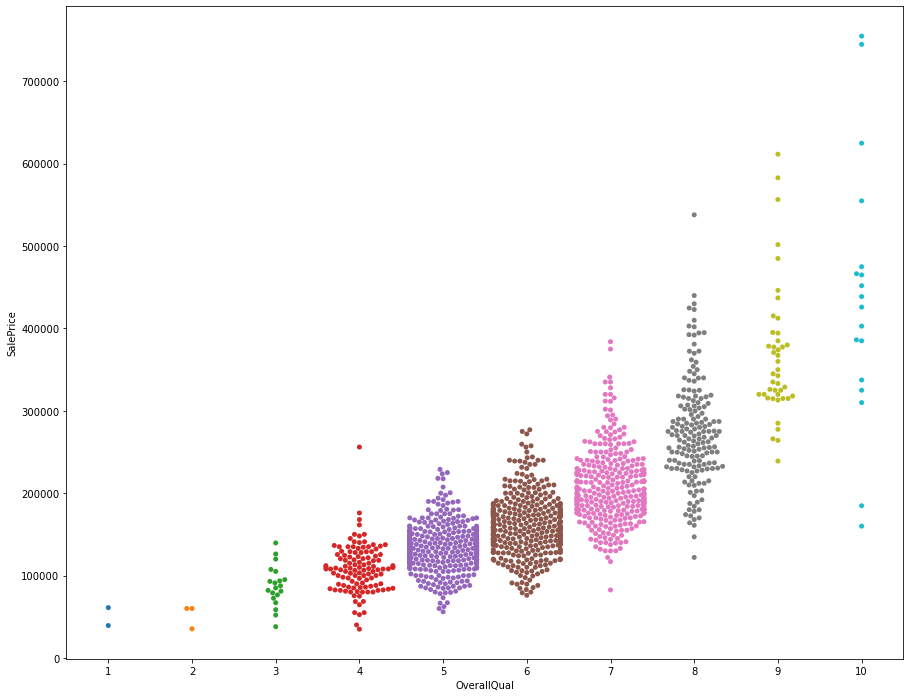

In [115]:
plt.figure(figsize= (15,12))

sns.swarmplot(data= housing_df,  x= "OverallQual", y="SalePrice")

plt.show()

In [ ]:
# Neighborhood wise Overall Quality:

In [129]:
crosstab = pd.crosstab(index=housing_df["Neighborhood"], columns=housing_df["OverallQual"])

In [130]:
crosstab

OverallQual,1,2,3,4,5,6,7,8,9,10
Neighborhood,,,,,,,,,,
Blmngtn,0,0,0,0,0,0,14,3,0,0
Blueste,0,0,0,0,0,2,0,0,0,0
BrDale,0,0,0,0,5,11,0,0,0,0
BrkSide,1,1,3,10,21,18,4,0,0,0
ClearCr,0,0,0,3,6,10,9,0,0,0
CollgCr,0,0,0,1,28,24,71,23,3,0
Crawfor,0,0,0,1,11,19,13,7,0,0
Edwards,1,0,5,25,38,23,5,0,1,2
Gilbert,0,0,0,1,3,33,36,5,1,0


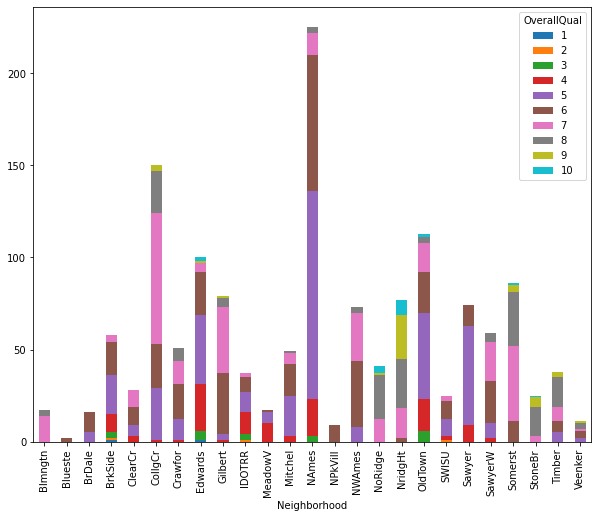

In [138]:
crosstab.plot(kind= "bar", stacked= True, figsize= (10,8))

plt.show()

In [ ]:
# Sale Condition Vs Sale Price:

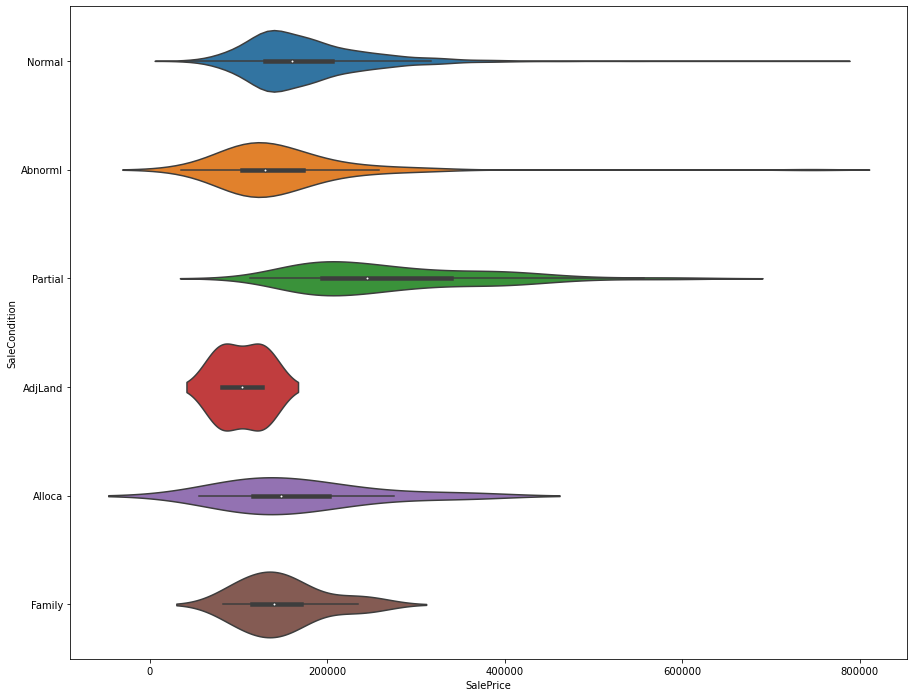

In [139]:
plt.figure(figsize= (15,12))

sns.violinplot(data= housing_df, x="SalePrice", y= "SaleCondition")

plt.show()

In [ ]:
# SaleCondition vs. SalesPrice for Different Neighborhood:

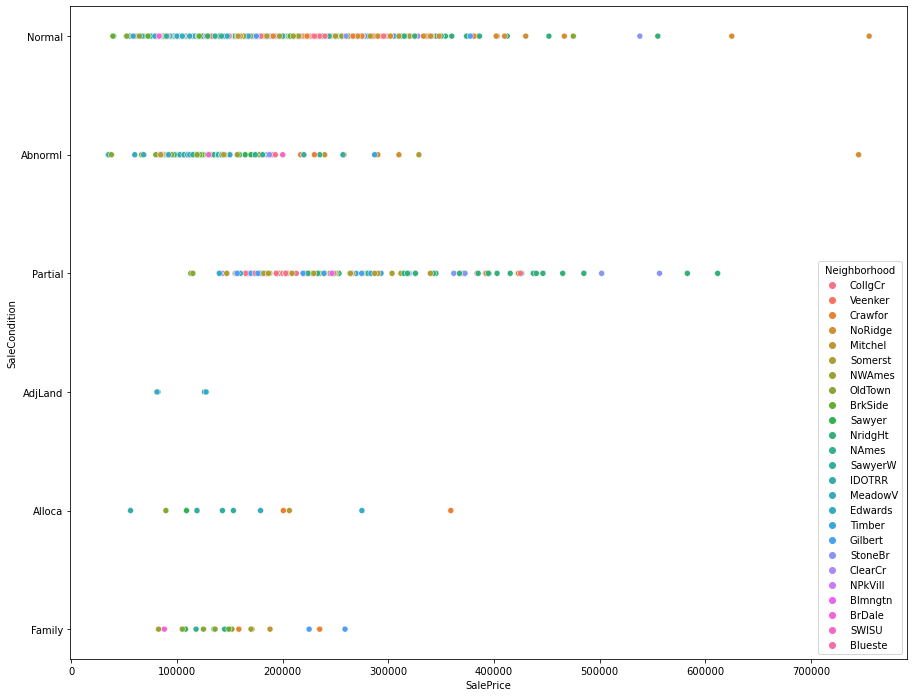

In [141]:
plt.figure(figsize= (15,12))

sns.scatterplot(data= housing_df, x="SalePrice", y= "SaleCondition", hue= "Neighborhood")

plt.show()

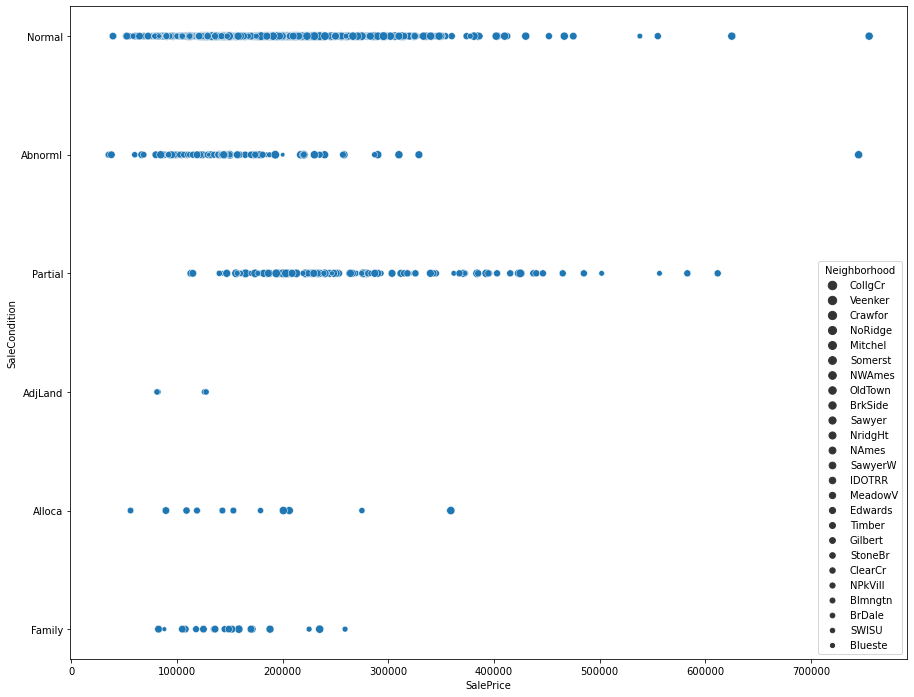

In [142]:
plt.figure(figsize= (15,12))

sns.scatterplot(data= housing_df, x="SalePrice", y= "SaleCondition", size= "Neighborhood")

plt.show()